# eCommerce Trading Engine — walkthrough

**What this brand's data actually says, which of it you can act on, and what the engine does about it.**

Twelve months of a D2C brand's operations: 26,553 orders, two ad platforms, six email flows, 24 product
variants. The brief describes a system that monitors performance, detects signals, recommends actions and
quantifies confidence. This notebook walks through what was built and — more importantly — what the data
turned out to be hiding.

There is one idea underneath everything here:

> **Four of the six findings read backwards on first look.** The metric that looks healthiest is the most
> dangerous one in the dataset. So the engine is built less to find things that moved, and more to tell
> apart the movements worth acting on from the ones that will cost you money if you do.

Every number below is computed live from the warehouse when this notebook runs. Nothing is typed in.

### Running this

```bash
cd dbt && ../venv/Scripts/dbt.exe build --profiles-dir .   # 20 models, 94 tests
cd .. && venv/Scripts/python.exe scripts/export_marts.py
venv/Scripts/python.exe -m jupyter lab notebooks/walkthrough.ipynb
```

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from engine.context import Warehouse

# House style, shared with the report and the wireframe.
INK, SIGNAL, MUTED, GRID = "#0F5F58", "#9C551A", "#5E6F72", "#DCE1DE"
plt.rcParams.update({
    "figure.figsize": (10, 4.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": "#2B3438",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.7,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "font.size": 10, "axes.titlesize": 11.5, "axes.titleweight": "600",
    "legend.frameon": False,
})

def date_axis(ax, label, fmt="%Y-%m", locator=None, rotation=45):
    # A readable date axis: named, formatted, and angled so ticks never collide.
    # Matplotlib draws date ticks horizontally by default, and they overlap as
    # soon as the labels are wider than the spacing - immediately, for YYYY-MM.
    if locator is not None:
        ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))
    ax.set_xlabel(label)
    for tick in ax.get_xticklabels():
        tick.set_rotation(rotation)
        tick.set_horizontalalignment("right")
        tick.set_rotation_mode("anchor")


warehouse = Warehouse()
ctx = warehouse.at(warehouse.latest_cursor)

print(f"Warehouse loaded, as of {warehouse.last_day}")
print(f"  {len(warehouse.daily):,} daily trading rows   "
      f"{len(warehouse.retention):,} cohort rows   {len(warehouse.ltv):,} LTV rows")

Warehouse loaded, as of 2025-06-30
  1,460 daily trading rows   132 cohort rows   144 LTV rows


---
## 1. The headline: it now costs nearly twice as much to earn a pound

Two numbers matter more than any others here. What a customer costs to acquire, and what that customer
is worth. Both moved the wrong way at once.

The chart plots them on the same axis deliberately — the point is that the lines converge, and a second
axis would let you hide that.

findfont: Failed to find font weight 600, now using 700.


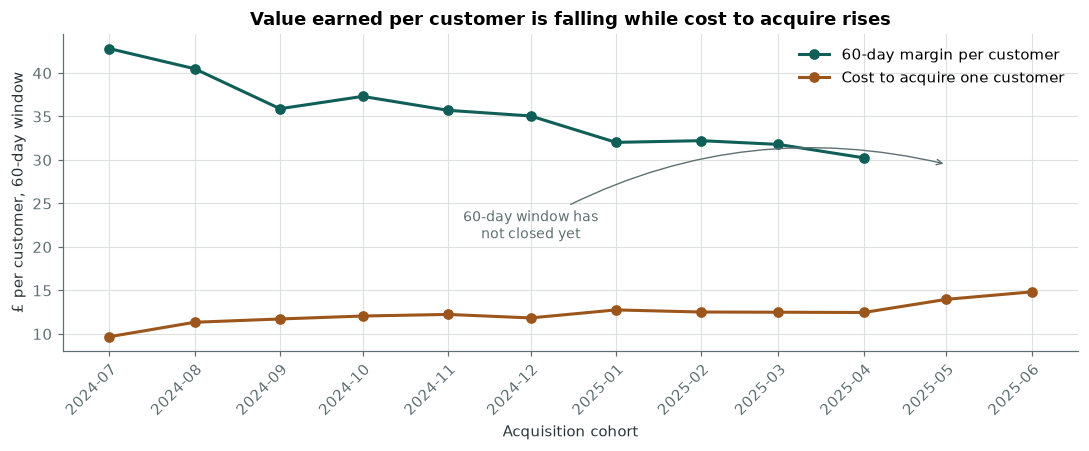

LTV/CAC   2024-07-01  4.42x
          2025-04-01  2.43x     (-45%)

Cost per customer   £9.68 -> £14.84  (+53%)
Value per customer  £42.81 -> £30.24  (-29%)


In [2]:
ltv = ctx.ltv[(ctx.ltv["horizon_days"] == 60) & ctx.ltv["has_full_exposure"].astype(bool)]
by_cohort = (ltv.groupby("cohort_month")
             .apply(lambda g: np.average(g["ltv_margin"].astype(float), weights=g["cohort_size"]))
             .rename("ltv_60d").reset_index())

daily = warehouse.daily.copy()
daily["cohort_month"] = pd.to_datetime(daily["date_day"]).values.astype("datetime64[M]")
cac = (daily[daily["ad_spend_is_complete"].astype(bool)]
       .groupby("cohort_month")
       .apply(lambda g: g["ad_spend"].astype(float).sum() / g["new_customers"].sum())
       .rename("cac").reset_index())
cac["cohort_month"] = cac["cohort_month"].dt.date

merged = by_cohort.merge(cac, on="cohort_month", how="outer").sort_values("cohort_month")
merged["ratio"] = merged["ltv_60d"] / merged["cac"]

fig, ax = plt.subplots()
ax.plot(merged["cohort_month"], merged["ltv_60d"], "o-", color=INK, lw=2,
        label="60-day margin per customer")
ax.plot(merged["cohort_month"], merged["cac"], "o-", color=SIGNAL, lw=2,
        label="Cost to acquire one customer")
ax.set_ylabel("£ per customer, 60-day window")
ax.set_title("Value earned per customer is falling while cost to acquire rises")
date_axis(ax, "Acquisition cohort", locator=mdates.MonthLocator())
ax.legend(loc="upper right")
ax.annotate("60-day window has\nnot closed yet",
            xy=(merged["cohort_month"].iloc[-2], 29.5),
            xytext=(merged["cohort_month"].iloc[5], 21),
            color=MUTED, fontsize=9, ha="center",
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.9,
                            connectionstyle="arc3,rad=-0.2"))
plt.tight_layout(); plt.show()

exposed = merged.dropna(subset=["ratio"])
first, last = exposed.iloc[0], exposed.iloc[-1]
print(f"LTV/CAC   {first['cohort_month']}  {first['ratio']:.2f}x")
print(f"          {last['cohort_month']}  {last['ratio']:.2f}x     "
      f"({100*(last['ratio']/first['ratio']-1):+.0f}%)")
print()
print(f"Cost per customer   £{first['cac']:.2f} -> £{merged['cac'].iloc[-1]:.2f}  "
      f"({100*(merged['cac'].iloc[-1]/first['cac']-1):+.0f}%)")
print(f"Value per customer  £{first['ltv_60d']:.2f} -> £{last['ltv_60d']:.2f}  "
      f"({100*(last['ltv_60d']/first['ltv_60d']-1):+.0f}%)")

**In plain terms.** A customer acquired last July returned about four and a half times what they cost.
A customer acquired in April returns under two and a half times. Neither the cost rise nor the value
fall would look alarming on its own — together they have nearly halved the return on every pound spent
acquiring customers.

Note the cost line keeps climbing after the value line stops. That is not a gap in the data: a customer
acquired in June has not yet had 60 days to spend, so their value is genuinely unknown. The engine
returns blank there rather than a number, for reasons the next section makes concrete.

---
## 2. The trap: the healthiest-looking metric in the dataset

If you asked "are customers coming back?", the obvious metric says yes. It has been flat around 24% all
year.

That metric is the most dangerous number here.

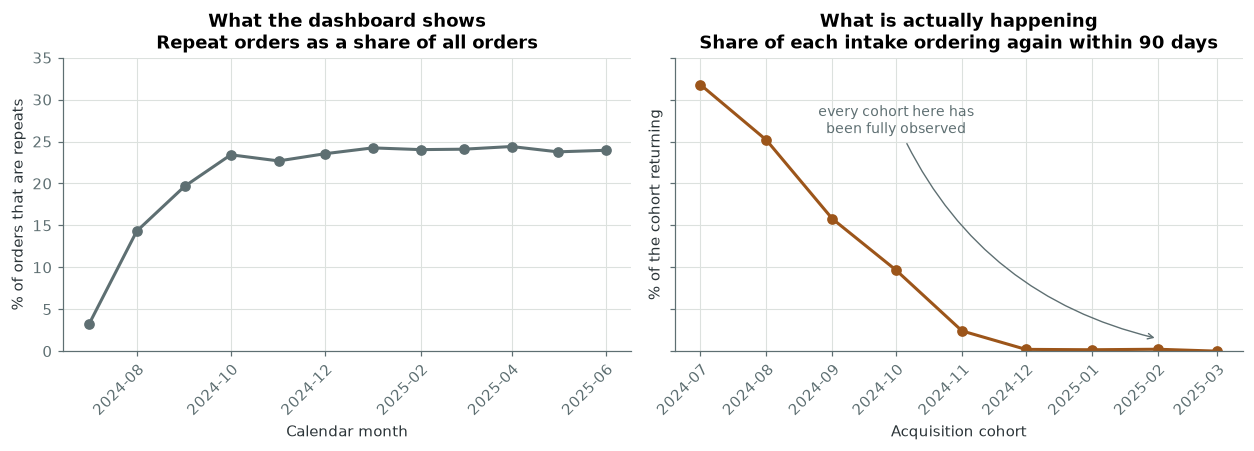

90-day repeat rate by acquisition cohort, fully observed only:
  2024-07   31.77%
  2024-08   25.17%
  2024-09   15.79%
  2024-10    9.65%
  2024-11    2.41%
  2024-12    0.21%
  2025-01    0.17%
  2025-02    0.23%
  2025-03    0.00%


In [3]:
daily_all = warehouse.daily.copy()
daily_all["month"] = pd.to_datetime(daily_all["date_day"]).values.astype("datetime64[M]")
blended = (daily_all.groupby("month")
           .apply(lambda g: g["returning_customers"].sum() / max(g["orders"].sum(), 1))
           .rename("repeat_share").reset_index())

cohorts = (ctx.retention[ctx.retention["has_full_90d_exposure"].astype(bool)]
           .groupby("cohort_month", as_index=False)
           .agg(rate=("repeat_rate_90d", "first")).sort_values("cohort_month"))

fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)

left.plot(blended["month"], 100 * blended["repeat_share"], "o-", color=MUTED, lw=2)
left.set_title("What the dashboard shows\nRepeat orders as a share of all orders")
left.set_ylabel("% of orders that are repeats")
left.set_ylim(0, 35)
date_axis(left, "Calendar month", locator=mdates.MonthLocator(interval=2))

right.plot(cohorts["cohort_month"], 100 * cohorts["rate"].astype(float), "o-",
           color=SIGNAL, lw=2)
right.set_title("What is actually happening\nShare of each intake ordering again within 90 days")
right.set_ylabel("% of the cohort returning")
right.set_ylim(0, 35)
date_axis(right, "Acquisition cohort", locator=mdates.MonthLocator())
right.annotate("every cohort here has\nbeen fully observed",
               xy=(cohorts["cohort_month"].iloc[-2], 1.5),
               xytext=(cohorts["cohort_month"].iloc[3], 26),
               color=MUTED, fontsize=9, ha="center",
               arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.9,
                               connectionstyle="arc3,rad=0.25"))
plt.tight_layout(); plt.show()

print("90-day repeat rate by acquisition cohort, fully observed only:")
for _, row in cohorts.iterrows():
    print(f"  {str(row['cohort_month'])[:7]}   {100*float(row['rate']):5.2f}%")

**Both charts are correct.** They have different denominators.

The left one measures the whole book — every order placed in a month, whoever placed it. It stays healthy
because customers acquired in mid-2024 are still buying. The right one follows each monthly *intake* and
asks whether those specific people came back.

**Essentially nobody acquired in 2025 returns.** The blended rate will keep looking fine right up until
the 2024 cohorts stop buying, and then fall off a cliff with no warning. It is a lagging indicator wearing
the costume of a current one.

Commercially this is the finding that should change behaviour: acquiring more customers into a book that
does not retain makes the problem bigger, not smaller. Which is why the engine's recommendation here is
*investigate*, not *spend differently*.

---
## 3. Four things that look like signals and are not

This is where most of the engineering went. A detector that fires on anything that moved is easy. The
hard part is staying quiet about the four cases below, each of which would produce a confident, expensive,
wrong decision.

### 3.1 Two days when the cost data simply did not arrive

Meta delivered no rows at all on 15 and 16 March. Orders arrived as normal. If you divide the spend you
*did* receive by the customers you *did* acquire, acquisition cost appears to fall by 40% — which reads
as excellent news.

In [4]:
gap_days = ["2025-03-15", "2025-03-16"]
window = warehouse.daily[
    warehouse.daily["date_day"].map(lambda d: "2025-03-12" <= str(d)[:10] <= "2025-03-19")
]
per_day = window.groupby("date_day").agg(
    spend=("ad_spend", "sum"), customers=("new_customers", "sum"),
    complete=("ad_spend_is_complete", "max"), published=("blended_cac", "max"),
).reset_index()
per_day["naive_cac"] = per_day["spend"] / per_day["customers"]

table = pd.DataFrame({
    "date": per_day["date_day"].map(lambda d: str(d)[:10]),
    "naive CAC (what a simple query returns)":
        per_day["naive_cac"].map(lambda v: f"£{v:,.2f}"),
    "what the warehouse publishes":
        per_day["published"].map(lambda v: "— not computable" if pd.isna(v) else f"£{float(v):,.2f}"),
})
display(table.style.hide(axis="index").map(
    lambda v: f"color:{SIGNAL};font-weight:600" if "not computable" in str(v) else ""))

clean = per_day[~per_day["date_day"].map(lambda d: str(d)[:10]).isin(gap_days)]
typical = float(clean["naive_cac"].mean())
understated = per_day[per_day["date_day"].map(lambda d: str(d)[:10]).isin(gap_days)]
print(f"\nTypical CAC that week:            £{typical:,.2f}")
print(f"What the gap days would report:   "
      f"£{understated['naive_cac'].iloc[0]:,.2f} and £{understated['naive_cac'].iloc[1]:,.2f}")
print(f"Understated by:                   "
      f"{100*(1-understated['naive_cac'].mean()/typical):.0f}%")

date,naive CAC (what a simple query returns),what the warehouse publishes
2025-03-12,£12.82,£12.82
2025-03-13,£11.40,£11.40
2025-03-14,£11.52,£11.52
2025-03-15,£6.75,— not computable
2025-03-16,£6.33,— not computable
2025-03-17,£11.08,£11.08
2025-03-18,£11.01,£11.01
2025-03-19,£12.50,£12.50



Typical CAC that week:            £11.72
What the gap days would report:   £6.75 and £6.33
Understated by:                   44%


A missing cost file always makes efficiency look better, never worse. An engine that cannot tell
*"costs fell"* from *"the cost file did not arrive"* will happily recommend more budget for a channel it
has merely stopped measuring. The warehouse flags the day as incomplete and publishes nothing, and the
detector that notices the gap suppresses every other signal whose evidence overlaps it.

### 3.2 Email engagement is falling. Do nothing.

Open rates are down across all six flows. The instinct is to rewrite the emails.

flow,open rate,conversion,orders still landing?
Browse Abandonment,38.0% -> 34.7%,0.96% -> 1.05%,yes
Cart Abandonment,45.2% -> 40.2%,4.24% -> 4.17%,yes
Post-Purchase,57.9% -> 52.1%,1.23% -> 1.17%,yes
Replenishment,41.2% -> 37.6%,2.13% -> 2.00%,yes
Welcome Series,52.0% -> 46.9%,3.28% -> 3.22%,yes
Win-Back,28.1% -> 25.1%,0.58% -> 0.53%,yes


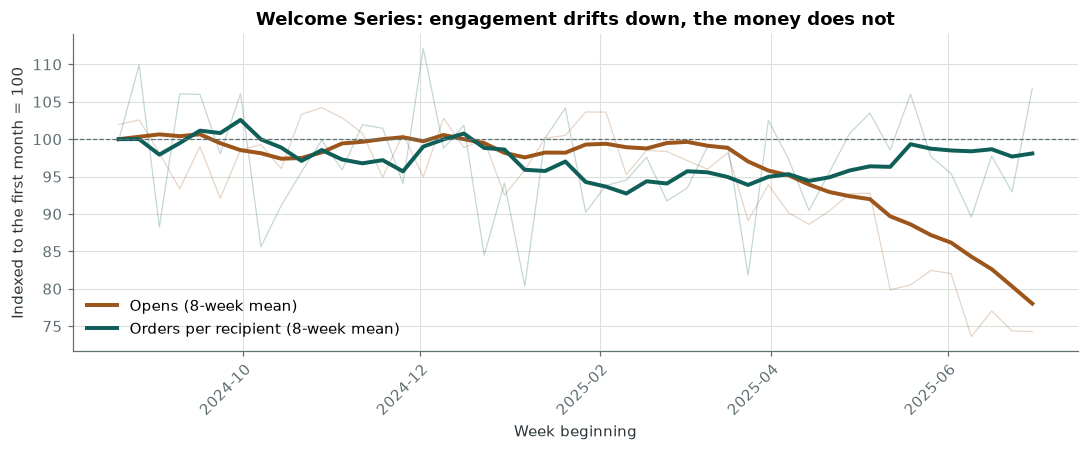

In [5]:
email = ctx.email.copy()
email["week_start"] = pd.to_datetime(email["week_start"])
rows = []
for flow, group in email.groupby("flow_name"):
    group = group.sort_values("week_start").iloc[7:]
    opens = group["open_rate"].dropna().astype(float)
    conv = group["conversion_rate"].dropna().astype(float)
    half = len(opens) // 2
    rows.append({
        "flow": flow,
        "open rate": f"{100*opens.iloc[:half].mean():.1f}% -> {100*opens.iloc[half:].mean():.1f}%",
        "conversion": f"{100*conv.iloc[:half].mean():.2f}% -> {100*conv.iloc[half:].mean():.2f}%",
        "orders still landing?": "yes" if conv.iloc[half:].mean() > 0.9 * conv.iloc[:half].mean() else "check",
    })
display(pd.DataFrame(rows).style.hide(axis="index"))

focus = email[email["flow_name"] == "Welcome Series"].sort_values("week_start").iloc[7:]
fig, ax = plt.subplots()

# Indexed to each series' own 8-week mean at the start of the visible window, so
# the two sit on one scale despite open rate being ~52% and conversion ~3.3%.
base_open = float(focus["open_rate_8w"].iloc[0])
base_conv = float(focus["conversion_rate_8w"].iloc[0])

# Raw weekly values faintly, so the noise is visible rather than hidden...
ax.plot(focus["week_start"], 100 * focus["open_rate"] / base_open,
        color=SIGNAL, lw=0.8, alpha=0.25)
ax.plot(focus["week_start"], 100 * focus["conversion_rate"] / base_conv,
        color=INK, lw=0.8, alpha=0.25)

# ...and the 8-week trailing mean boldly, which is where the trend actually is.
# Plotted raw, week to week, these two lines are indistinguishable noise and the
# whole point of the chart disappears.
ax.plot(focus["week_start"], 100 * focus["open_rate_8w"] / base_open,
        color=SIGNAL, lw=2.6, label="Opens (8-week mean)")
ax.plot(focus["week_start"], 100 * focus["conversion_rate_8w"] / base_conv,
        color=INK, lw=2.6, label="Orders per recipient (8-week mean)")
ax.axhline(100, color=MUTED, lw=0.8, ls="--")
ax.set_ylabel("Indexed to the first month = 100")
ax.set_title("Welcome Series: engagement drifts down, the money does not")
date_axis(ax, "Week beginning", locator=mdates.MonthLocator(interval=2))
ax.legend()
plt.tight_layout(); plt.show()

**Opens fell about 20%. Orders per recipient did not move.**

Open rate is a compromised measurement — privacy proxies inflate it, and the number drifts as a list ages.
Since the commercial outcome held, the honest reading is that the *measurement* changed, not the
programme. Rewriting flows that are still earning would be an expensive way to fix nothing.

The engine classifies all six flows as `ARTIFACT`. They appear in the output — they are not hidden — but
they cannot become an action.

### 3.3 Two zeros that mean opposite things

A cohort can read 0% for two completely different reasons: nobody came back, or nobody has had the chance
yet. Conflating them is the single easiest way to invent a crisis.

In [6]:
def month_three(cohort):
    row = ctx.retention[
        (ctx.retention["cohort_month"].map(lambda d: str(d)[:7]) == cohort)
        & (ctx.retention["months_since"] == 3)
    ]
    if row.empty:
        return None
    row = row.iloc[0]
    return {
        "cohort": cohort,
        "customers": int(row["cohort_size"]),
        "came back in month 3": int(row["repeat_customers"]),
        "window closed?": "yes" if row["has_full_exposure"] else "NOT YET",
        "published": ("—" if pd.isna(row["retention_rate"])
                      else f"{100*float(row['retention_rate']):.1f}%"),
    }

pair = pd.DataFrame([month_three("2024-10"), month_three("2025-04")])
display(pair.style.hide(axis="index").map(
    lambda v: f"color:{SIGNAL};font-weight:600" if v in ("NOT YET", "—") else ""))

print("Both cohorts have the same raw count at month three.")
print("One is a measured result. The other has not happened yet.")
print("The median gap between a first and second order is 100 days, so the")
print("April cohort could not have repeated by the time the data ends.")

cohort,customers,came back in month 3,window closed?,published
2024-10,1730,0,yes,0.0%
2025-04,1586,0,NOT YET,—


Both cohorts have the same raw count at month three.
One is a measured result. The other has not happened yet.
The median gap between a first and second order is 100 days, so the
April cohort could not have repeated by the time the data ends.


The warehouse publishes a number for the first and nothing for the second, and two tests enforce it in
**both** directions — one fails if a censored value is ever published, the other fails if the guard grows
so aggressive it starts hiding real data. It would be easy to write a guard that suppresses the entire
retention decline and reports everything as "too early to say"; that would be just as wrong, in the
opposite direction.

### 3.4 Peak season, when everything looks exceptional

In late November every product sells faster than its own recent average — because it is late November.
A detector comparing each product against its own history flagged **23 of the 24 variants**, which is
another way of saying it detected nothing.

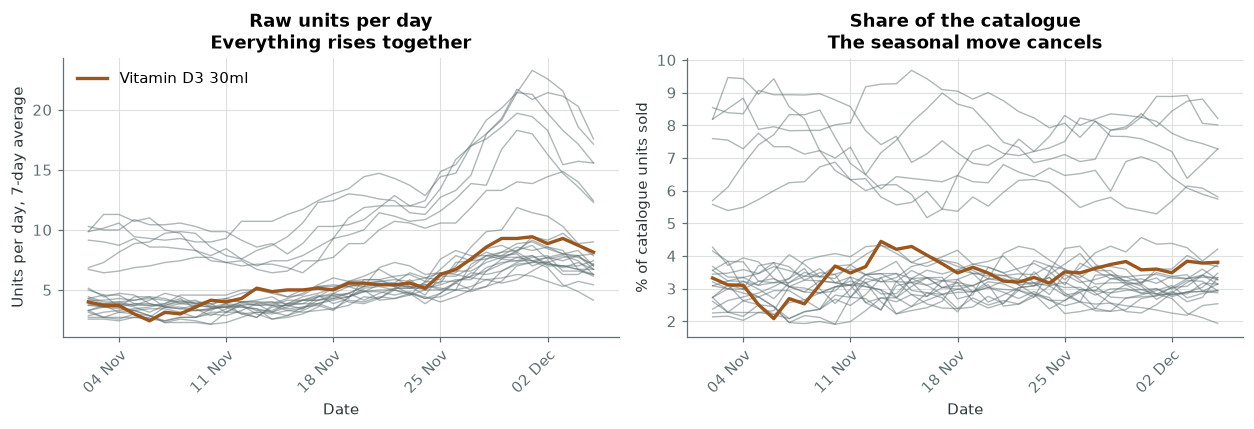

In [7]:
product = warehouse.product.copy()
product["date_day"] = pd.to_datetime(product["date_day"])
peak = product[(product["date_day"] > "2024-11-01") & (product["date_day"] <= "2024-12-05")]

totals = peak.groupby("date_day")["velocity_7d"].sum()
d3 = peak[peak["sku"] == "VIT-D3-30ML"]

fig, (left, right) = plt.subplots(1, 2, figsize=(11.5, 4.0))
for sku, group in peak.groupby("sku"):
    left.plot(group["date_day"], group["velocity_7d"], color=MUTED, lw=0.9, alpha=0.5)
left.plot(d3["date_day"], d3["velocity_7d"], color=SIGNAL, lw=2.2, label="Vitamin D3 30ml")
left.set_title("Raw units per day\nEverything rises together")
left.set_ylabel("Units per day, 7-day average")
date_axis(left, "Date", fmt="%d %b",
          locator=mdates.WeekdayLocator(byweekday=mdates.MO))
left.legend()

for sku, group in peak.groupby("sku"):
    share = group["velocity_7d"].to_numpy() / group["date_day"].map(totals).to_numpy()
    right.plot(group["date_day"], 100 * share, color=MUTED, lw=0.9, alpha=0.5)
right.plot(d3["date_day"], 100 * d3["velocity_7d"].to_numpy() / d3["date_day"].map(totals).to_numpy(),
           color=SIGNAL, lw=2.2)
right.set_title("Share of the catalogue\nThe seasonal move cancels")
right.set_ylabel("% of catalogue units sold")
date_axis(right, "Date", fmt="%d %b",
          locator=mdates.WeekdayLocator(byweekday=mdates.MO))
plt.tight_layout(); plt.show()

Measuring each product as a **share of the catalogue** removes the common seasonal move exactly, with no
seasonal model to fit — which matters, because twelve months of data contains exactly one November and an
annual pattern cannot be estimated from a single observation of it.

What survives is genuine relative movement, which is what the real finding always was: Vitamin D3 tripled
*while the other eleven products stayed flat*. Making this change took the engine's precision from 35% to
76%.

---
## 4. Why Meta got more expensive — and why that changes the answer

Meta's cost per click rose sharply. "Cost per click is up" is not yet an actionable statement, because it
has two possible causes that call for opposite responses.

Cost per click is auction price divided by how often people click. So:

- **Auction price up, clicking unchanged** → you are paying more for the same audience. Changing the ads
  will not help; this is a budget or targeting decision.
- **Clicking down** → the creative is wearing out. Changing the ads is exactly what helps.

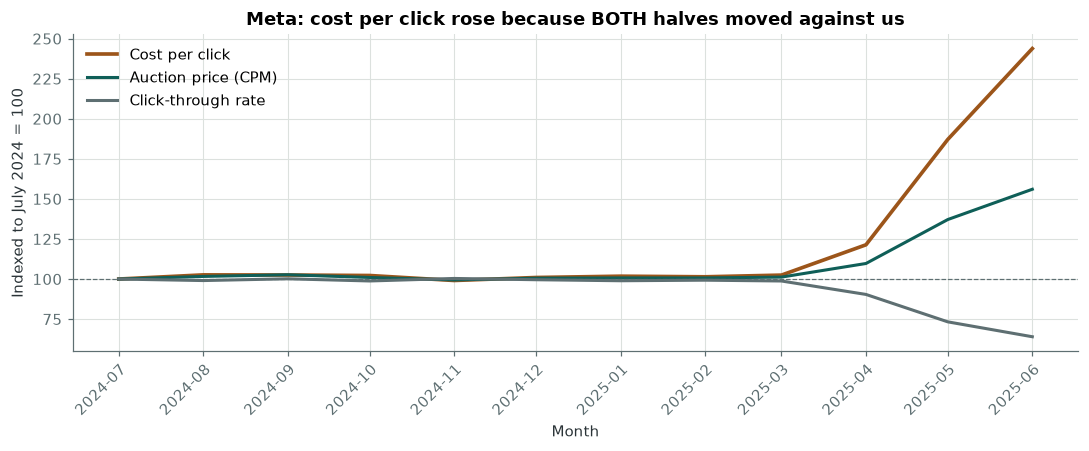

Cost per click       £0.42 -> £1.02   (+144%)
Auction price (CPM)  £9.93 -> £15.50   (+56%)   <- not fixable with creative
Click-through rate   2.38% -> 1.52%   (-36%)   <- is fixable with creative


In [8]:
ads = warehouse.ads.copy()
ads["ad_date"] = pd.to_datetime(ads["ad_date"])
meta = ads[ads["platform"] == "meta"]
monthly = meta.groupby(meta["ad_date"].values.astype("datetime64[M]")).agg(
    spend=("spend", "sum"), clicks=("clicks", "sum"), impressions=("impressions", "sum"))
# The warehouse stores money as DECIMAL for exact reconciliation; cast once here
# so the indexing arithmetic below is plain float.
monthly = monthly.astype(float)
monthly["cpc"] = monthly["spend"] / monthly["clicks"]
monthly["cpm"] = 1000 * monthly["spend"] / monthly["impressions"]
monthly["ctr"] = monthly["clicks"] / monthly["impressions"]

idx = monthly / monthly.iloc[0]
fig, ax = plt.subplots()
ax.plot(idx.index, 100 * idx["cpc"], color=SIGNAL, lw=2.4, label="Cost per click")
ax.plot(idx.index, 100 * idx["cpm"], color=INK, lw=2, label="Auction price (CPM)")
ax.plot(idx.index, 100 * idx["ctr"], color=MUTED, lw=2, label="Click-through rate")
ax.axhline(100, color=MUTED, lw=0.8, ls="--")
ax.set_ylabel("Indexed to July 2024 = 100")
ax.set_title("Meta: cost per click rose because BOTH halves moved against us")
date_axis(ax, "Month", locator=mdates.MonthLocator())
ax.legend()
plt.tight_layout(); plt.show()

first, last = monthly.iloc[0], monthly.iloc[-1]
print(f"Cost per click       £{first['cpc']:.2f} -> £{last['cpc']:.2f}   "
      f"({100*(last['cpc']/first['cpc']-1):+.0f}%)")
print(f"Auction price (CPM)  £{first['cpm']:.2f} -> £{last['cpm']:.2f}   "
      f"({100*(last['cpm']/first['cpm']-1):+.0f}%)   <- not fixable with creative")
print(f"Click-through rate   {100*first['ctr']:.2f}% -> {100*last['ctr']:.2f}%   "
      f"({100*(last['ctr']/first['ctr']-1):+.0f}%)   <- is fixable with creative")

Both moved. Roughly half the damage is auction inflation you cannot control, and half is creative
relevance you can.

That split is the recommendation. Refresh creative to address the half that responds to it, and size any
budget reallocation to the *auction-attributable half only* — because shifting budget away from a channel
whose problem is fixable in place would be moving money for the wrong reason.

---
## 5. The engine, running

Everything above is what the engine was built to conclude on its own. Here it is at the most recent date.

In [9]:
from engine.run import detect, signals_frame

signals = signals_frame(detect(ctx))
view = signals[["detector", "entity_id", "classification", "attribution_tier",
                "confidence", "is_actionable"]].copy()
view.columns = ["detector", "what", "verdict", "evidence tier", "confidence", "actionable"]
display(view.style.hide(axis="index").map(
    lambda v: (f"color:{INK};font-weight:600" if v == "COMMERCIAL"
               else f"color:{SIGNAL}" if v == "DATA_QUALITY"
               else f"color:{MUTED}" if v == "ARTIFACT" else ""),
    subset=["verdict"]))

print(f"{len(signals)} signals — {int(signals['is_actionable'].sum())} of them actionable.")
print()
print("Verdicts mean:")
print("  COMMERCIAL    a real business movement; may become an action")
print("  ARTIFACT      real movement, but not commercial; must NOT become an action")
print("  DATA_QUALITY  a pipeline problem wearing a business movement's clothes")

detector,what,verdict,evidence tier,confidence,actionable
cohort_retention_shift,all,COMMERCIAL,B,0.950000,True
cac_trend,blended,COMMERCIAL,B,0.886500,True
inventory_cover,VIT-CBD20-30ML,COMMERCIAL,A,0.550000,True
inventory_cover,VIT-BALM-100ML,COMMERCIAL,A,0.550000,True
channel_cvr_shift,meta,COMMERCIAL,C,0.484700,True
cpc_decomposition,meta,COMMERCIAL,A,0.472900,True
cac_ltv_breach,meta,COMMERCIAL,C,0.331000,True
cac_trend,meta,COMMERCIAL,C,0.327500,True
data_completeness,meta_ads_daily,DATA_QUALITY,A,0.666700,False
email_engagement_decay,Win-Back,ARTIFACT,B,0.572700,False


15 signals — 8 of them actionable.

Verdicts mean:
  COMMERCIAL    a real business movement; may become an action
  ARTIFACT      real movement, but not commercial; must NOT become an action
  DATA_QUALITY  a pipeline problem wearing a business movement's clothes


Note what is **not** actionable. Every email flow is an artifact. The Meta outage is a data-quality
problem. Of twelve signals, four can drive a decision — and the engine says why for the rest rather than
silently dropping them.

The **evidence tier** column matters more than it looks. `landing_site` carries no UTM parameters on any
of the 26,553 orders, so last-click referrer is the only attribution available and 26.8% of orders cannot
be attributed at all. Anything depending on it is Tier C, and a Tier C signal is capped at 0.55 confidence
no matter how strong it looks — which is below the threshold for acting without a human.

---
## 6. A recommendation, with its uncertainty attached

The brief's own example is *"recommend reallocating 20% of Meta budget to Google"*. Here is that
recommendation with the thing that makes it trustworthy: a range instead of a number.

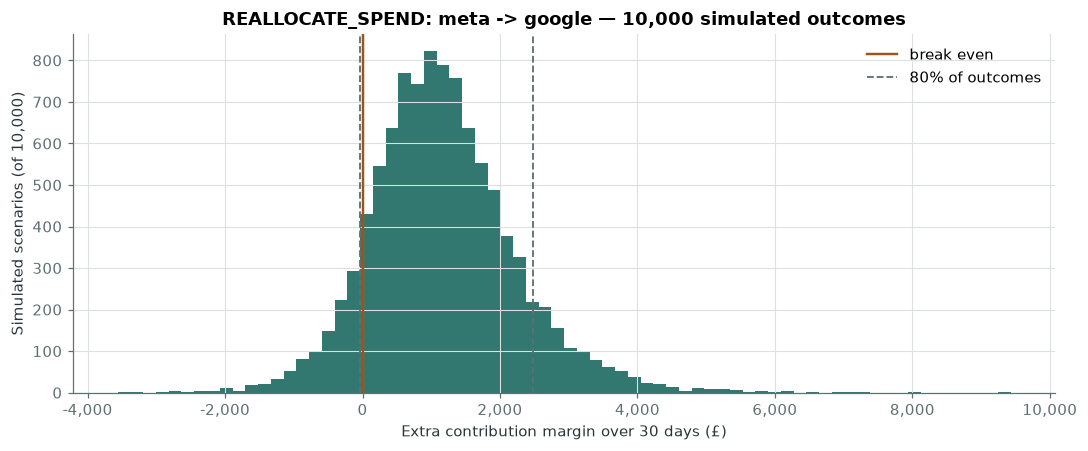

Action        REALLOCATE_SPEND  (0.2 share of donor budget)
Decision      AUTO-EXECUTE

Most likely   £1,088 extra margin over 30 days
Range         £-34 to £2,481 (80% of simulated outcomes)
Odds it pays  89%

  - bounded test: the cost evidence is Tier B but the incremental-revenue evidence is Tier C, so the shift is sized to the weaker half
  - also raised by cpc_decomposition at confidence 0.47
  - also raised by cac_trend at confidence 0.33


In [10]:
from engine.recommend import dedupe, recommend

recs = dedupe(recommend(ctx, signals))
spend_moves = [r for r in recs if r.outcome is not None and r.outcome.p_positive is not None]
pick = max(spend_moves, key=lambda r: r.confidence)
summary = pick.outcome.summary()

fig, ax = plt.subplots()
draws = pick.outcome.draws
ax.hist(draws, bins=70, color=INK, alpha=0.85)
ax.axvline(0, color=SIGNAL, lw=1.6, label="break even")
ax.axvline(summary["ci80_low"], color=MUTED, ls="--", lw=1.2)
ax.axvline(summary["ci80_high"], color=MUTED, ls="--", lw=1.2, label="80% of outcomes")
ax.set_xlabel("Extra contribution margin over 30 days (£)")
ax.set_ylabel("Simulated scenarios (of 10,000)")
ax.xaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_title(f"{pick.action_type}: {pick.entity_id} — 10,000 simulated outcomes")
ax.legend()
plt.tight_layout(); plt.show()

print(f"Action        {pick.action_type}  ({pick.magnitude:g} {pick.magnitude_unit})")
print(f"Decision      {pick.autonomy}")
print()
print(f"Most likely   £{summary['median']:,.0f} extra margin over 30 days")
print(f"Range         £{summary['ci80_low']:,.0f} to £{summary['ci80_high']:,.0f} "
      f"(80% of simulated outcomes)")
print(f"Odds it pays  {summary['p_positive']:.0%}")
print()
for note in pick.notes:
    print(f"  - {note}")

**Why a range rather than a number.** With retention collapsing and a quarter of orders unattributed,
"this will earn £1,108" is a claim the data cannot support. The range is honest about what is actually
known, and it is what lets the engine decide *how hard to act* rather than merely *whether to*.

Two rules govern that decision:

- **Reversibility sets the ceiling.** Ad spend can be unwound tomorrow, so it can be automatic. An
  inventory purchase cannot be unspent, so it is reviewed by a human at *any* confidence.
- **Confidence sets the size.** In the middle band the action still happens, capped small enough that
  being wrong is cheap.

There is a third rule that was added after watching the engine misbehave. It originally recommended a
creative refresh whose own simulation gave it a **13% chance of paying**, with a most-likely outcome of
*minus* £817 — because confidence measured whether the *signal* was real, and nobody had asked whether
*acting on it* was worth doing. Those are different questions. The engine now refuses any action its own
simulation rejects.

In [11]:
rows = []
for r in sorted(recs, key=lambda r: -r.confidence):
    s = r.outcome.summary() if r.outcome else {}
    rows.append({
        "action": r.action_type,
        "what": r.entity_id,
        "decision": r.autonomy,
        "reversible": r.reversibility,
        "odds it pays": ("—" if not s or s.get("p_positive") is None
                         else f"{s['p_positive']:.0%}"),
    })
display(pd.DataFrame(rows).style.hide(axis="index").map(
    lambda v: (f"color:{INK};font-weight:600" if v == "AUTO-EXECUTE"
               else f"color:{SIGNAL}" if v == "FLAG FOR REVIEW" else ""),
    subset=["decision"]))

action,what,decision,reversible,odds it pays
INVESTIGATE_DATA,all,FLAG FOR REVIEW,reversible,—
REALLOCATE_SPEND,meta -> google,AUTO-EXECUTE,reversible,89%
INVESTIGATE_DATA,meta_ads_daily,MONITOR,reversible,—
INVESTIGATE_DATA,Win-Back,MONITOR,reversible,—
REORDER_INVENTORY,VIT-CBD20-30ML,FLAG FOR REVIEW,irreversible,—
REORDER_INVENTORY,VIT-BALM-100ML,FLAG FOR REVIEW,irreversible,—
INVESTIGATE_DATA,Cart Abandonment,MONITOR,reversible,—
INVESTIGATE_DATA,Post-Purchase,MONITOR,reversible,—
INVESTIGATE_DATA,Replenishment,MONITOR,reversible,—
INVESTIGATE_DATA,Welcome Series,MONITOR,reversible,—


One action runs unattended. Two inventory reorders are flagged for a human because capital cannot be
un-spent. Everything else is watched, not acted on.

---
## 7. Does any of it work?

The engine can be replayed as of any past date, seeing only data that had actually arrived by then. That
lets us ask a fair question: *would it have caught these things at the time, without hindsight?*

In [12]:
from engine.backtest import replay, score

result = replay(warehouse, step_days=3)
report = score(result)

events = report["events"].copy()
events["lead_days"] = events["lead_days"].map(lambda v: "—" if pd.isna(v) else f"{int(v):+d} days")
events.columns = ["what happened", "detector", "when it started", "first detected",
                  "detected after", "days it stayed up", "found?"]
display(events.style.hide(axis="index"))

traps = report["traps"].copy()
traps.columns = ["trap it had to avoid", "detector", "false alarms", "days affected", "stayed quiet?"]
display(traps.style.hide(axis="index").map(
    lambda v: f"color:{INK};font-weight:600" if v is True else
              (f"color:{SIGNAL};font-weight:600" if v is False else ""),
    subset=["stayed quiet?"]))

print(f"Found          {int(report['events']['detected'].sum())} of "
      f"{len(report['events'])} real events")
print(f"False alarms   {report['trap_violations']} across all four traps")
print(f"Replay         {report['cursors']} dates in {report['seconds']:.0f} seconds")

what happened,detector,when it started,first detected,detected after,days it stayed up,found?
meta_cost_inflation,cpc_decomposition,2025-04-01,2025-04-24,+23 days,23,True
blended_cac_rise,cac_trend,2024-10-01,2024-10-29,+28 days,13,True
cohort_retention_collapse,cohort_retention_shift,2025-01-31,2025-01-30,-1 days,39,True
meta_ingestion_gap,data_completeness,2025-03-15,2025-03-16,+1 days,36,True
aov_erosion,aov_decomposition,2025-02-01,2025-02-02,+1 days,1,True
d3_velocity_breakout,product_velocity,2025-02-01,2025-01-24,-8 days,35,True


trap it had to avoid,detector,false alarms,days affected,stayed quiet?
email_engagement_decay,email_engagement_decay,0,0,True
meta_spend_crash,cac_trend,0,0,True
january_trough,any,0,0,True
censored_recent_cohorts,cohort_retention_shift,0,0,True


Found          6 of 6 real events
False alarms   0 across all four traps
Replay         82 dates in 16 seconds


The second table matters more than the first. Anyone can build something that fires; the test is whether
it stays quiet on the four cases from section 3 — every one of which would have produced a confident,
expensive mistake.

**An honest caveat, stated rather than buried.** The list of "real events" is my own reading of the data,
written before the detectors were built — but written by the same person who then built them. So this
measures whether the engine does what it was designed to do. It is not independent validation, and a
perfect score here is not evidence the design was right.

---
## 8. What I would do next

**Score against outcomes, not against my own labels.** Right now "detected after 23 days" is measured
against a start date I chose. Measuring instead against a commercial outcome would be far stronger — but
needs someone to define what outcome counts, which no one has.

**Fix the LTV horizon.** A 60-day window is not comparable across cohorts. 14.4% of revenue arrives after
day 90, and almost all of it belongs to three early cohorts: the July 2024 intake earns 44.5% of its
revenue after day 90, every 2025 intake earns none. So a fixed window badly understates early cohorts and
is essentially complete for recent ones — which *flatters* recent cohorts and understates how far unit
economics have really moved. Comparing cohorts at equal observed age would be more defensible.

**Get the things the data cannot answer.** Three limits are structural, not fixable by better code:

| Gap | Consequence |
|---|---|
| No UTM parameters on any order | A quarter of orders unattributable; all channel figures discounted |
| No TikTok cost file | 9% of orders have no measurable acquisition cost at all |
| Inventory and cost are current snapshots | Days of cover is meaningful only today; cost changes during the year are invisible |

**Agree the thresholds.** Nothing in the brief says what an unhealthy LTV/CAC ratio is, or what days of
cover should trigger a reorder. Every threshold in this engine is my judgement, which is exactly why they
sit in `config/detectors.yml` and `config/actions.yml` where they can be argued with, rather than buried
in code.

---

### If you read nothing else

1. Unit economics have nearly halved — **4.42x to 2.43x** — and the cost half is still rising.
2. **Nobody acquired in 2025 comes back.** The stable-looking 24% repeat rate is hiding it, and will keep
   hiding it until it suddenly does not.
3. The most valuable thing built here is not the detection. It is the four cases where the engine
   deliberately **says nothing**.